## Assignment – High Frequency Words

### Please answer the following questions in an IPython Notebook, posted to GitHub.
1. Choose a corpus of interest.
2. How many total unique words are in the corpus? (Please feel free to define unique words in any interesting,
defensible way).
3. Taking the most common words, how many unique words represent half of the total words in the corpus?
4. Identify the 200 highest frequency words in this corpus.
5. Create a graph that shows the relative frequency of these 200 words.
6. Does the observed relative frequency of these words follow Zipf’s law? Explain.
7. In what ways do you think the frequency of the words in this corpus differ from “all words in all corpora.”

#### Reading in my libs for the notebook

In [1]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import nltk
from nltk.corpus import reuters

#### 1. Choose a corpus of interest.
Firstly, pulling in my text that im going to use. Reuters News from NLTK. 
This corpus contains newswire text. For the sake of this  analysis, a word is considered a lowercase alphabetic token. Punctuation, numbers, and capitalization differences are removed.


In [2]:
nltk.download('reuters', quiet=True)
reuters_words = reuters.words()
print("Total raw tokens in Reuters corpus:", len(reuters_words))
print("First 20 tokens:", reuters_words[:20])

Total raw tokens in Reuters corpus: 1720901
First 20 tokens: ['ASIAN', 'EXPORTERS', 'FEAR', 'DAMAGE', 'FROM', 'U', '.', 'S', '.-', 'JAPAN', 'RIFT', 'Mounting', 'trade', 'friction', 'between', 'the', 'U', '.', 'S', '.']


#### 2. How many total unique words are in the corpus? (Please feel free to define unique words in any interesting, defensible way).
As mentioned before, a word is defined as a lowercase alphabetic token without the punctuation characters. The cleaned words are all lower case.

 
 NOTE: instances like "u.s." will be considered two different tokens ("u" and "s"), which is fine because it actually means "united states". However we arent replacing these two tokens with "united" and "states" respectively. Im just making a note of it here, if we need to come back and do something like that we can.

In [3]:
clean_words = []
for word in reuters_words:
    word = word.lower()
    if re.fullmatch(r"[a-z]+", word):
        clean_words.append(word)
print("Total cleaned words:", len(clean_words))
print("First 20 cleaned words:", clean_words[:20])

Total cleaned words: 1327140
First 20 cleaned words: ['asian', 'exporters', 'fear', 'damage', 'from', 'u', 's', 'japan', 'rift', 'mounting', 'trade', 'friction', 'between', 'the', 'u', 's', 'and', 'japan', 'has', 'raised']


#### 3. Taking the most common words, how many unique words represent half of the total words in the corpus?


In [6]:
word_counts = Counter(clean_words)
total_words = len(clean_words)
unique_words = len(set(clean_words))
print("Total words in cleaned corpus:", total_words)
print("Total unique words in cleaned corpus:", unique_words)

Total words in cleaned corpus: 1327140
Total unique words in cleaned corpus: 29172


In [7]:
### Looking at the representation of half the total corpus. 
half_total = total_words / 2
running_total = 0
words_needed_for_half = 0

## Looping through for the words that are most common to get through half the corpus for answer
for word, count in word_counts.most_common():
    running_total += count
    words_needed_for_half += 1
    if running_total >= half_total:
        break
print("Number of unique words needed to account for half the corpus:", words_needed_for_half)

Number of unique words needed to account for half the corpus: 108


#### 4. Identify the 200 highest frequency words in this corpus.


In [24]:
### Using the word_counts var established abovbe and limiting to the 200 most common
top_200 = word_counts.most_common(200)
### into a DF for viewing and viz
top_200_df = pd.DataFrame(top_200, columns=["word", "count"])
### looking at the top 20 rows, so top 20 words
top_200_df.head(20)
## For charting
top_200_df["relative_frequency"] = top_200_df["count"] / total_words
pd.options.display.max_rows = 200
top_200_df.head(n=200)

,word,count,relative_frequency
0,the,69277,0.052200
1,of,36779,0.027713
2,to,36400,0.027427
3,in,29253,0.022042
4,and,25648,0.019326
5,said,25383,0.019126
6,a,25103,0.018915
7,mln,18623,0.014032
8,s,15680,0.011815
9,vs,14341,0.010806


#### 5. Create a graph that shows the relative frequency of these 200 words.

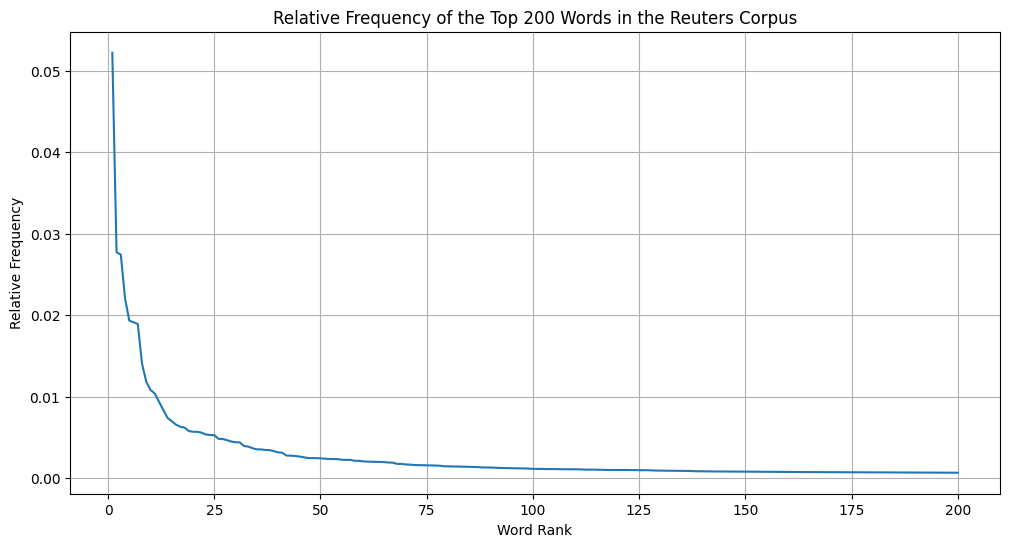

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 201), top_200_df["relative_frequency"])
plt.xlabel("Word Rank")
plt.ylabel("Relative Frequency")
plt.title("Relative Frequency of the Top 200 Words in the Reuters Corpus")
plt.grid(True)
plt.show()

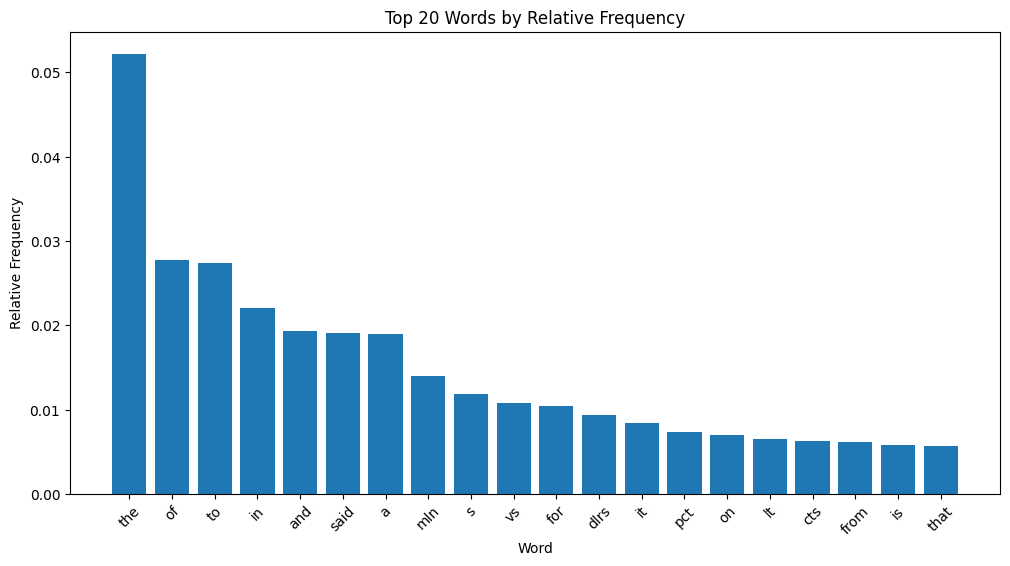

In [18]:
plt.figure(figsize=(12, 6))
plt.bar(top_200_df["word"][:20], top_200_df["relative_frequency"][:20])
plt.xlabel("Word")
plt.ylabel("Relative Frequency")
plt.title("Top 20 Words by Relative Frequency")
plt.xticks(rotation=45)
plt.show()

The chart above shows that the frwequency of the most common 200 words, generally, have a much higher frequency of showing up than others. Even those words that are in the top 25 words, are present in a much higher frequency than those in the top 26th through 75th words. THe same thing can be said about the most common 10 words, when compared to those in the top 11th through 20th positions. Lastly, after about the top 100 words, the frequency of those in the top 101 through 200 spots have a reletively constant freq

There was no filtering out of transition words, so these top ten words are essentially ones like "the", "is", "of", "to", "in", etc. These are basically "stop words". 

#### Without Stop words

In [25]:
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

### Removing stop words from clean words
no_stop_words = [word for word in clean_words if word not in stop_words]
print("Total words after removing stopwords:", len(no_stop_words))
word_counts_no_stop = Counter(no_stop_words)
top_200_no_stop = word_counts_no_stop.most_common(200)
top_200_no_stop_df = pd.DataFrame(top_200_no_stop, columns=["word", "count"])
top_200_no_stop_df["relative_frequency"] = top_200_no_stop_df["count"] / len(no_stop_words)
top_200_no_stop_df.head(n=200)

Total words after removing stopwords: 871515


,word,count,relative_frequency
0,said,25383,0.029125
1,mln,18623,0.021369
2,vs,14341,0.016455
3,dlrs,12417,0.014248
4,pct,9810,0.011256
5,lt,8696,0.009978
6,cts,8361,0.009594
7,year,7529,0.008639
8,net,6989,0.008019
9,u,6392,0.007334


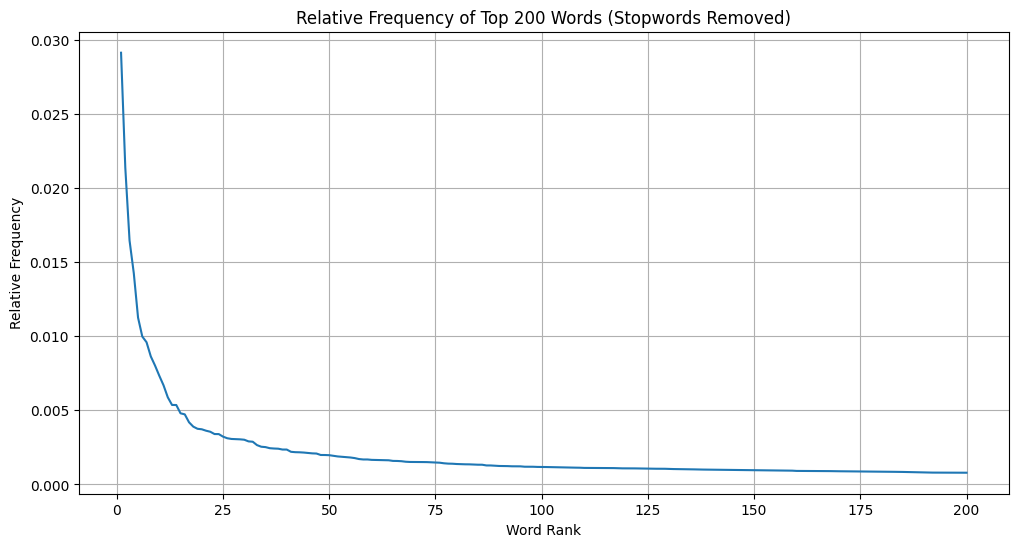

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 201), top_200_no_stop_df["relative_frequency"])
plt.xlabel("Word Rank")
plt.ylabel("Relative Frequency")
plt.title("Relative Frequency of Top 200 Words (Stopwords Removed)")
plt.grid(True)
plt.show()

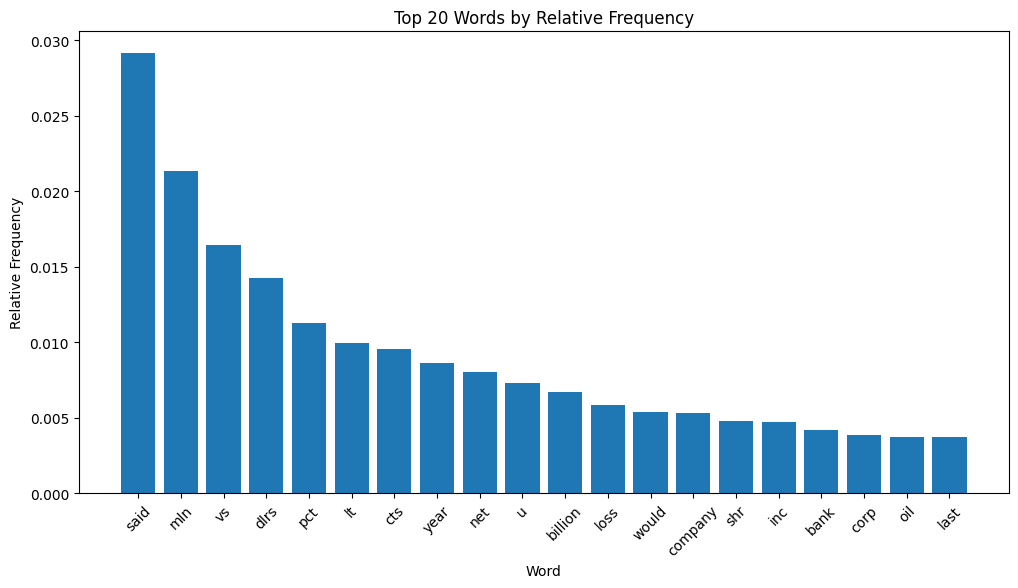

In [21]:
plt.figure(figsize=(12, 6))
plt.bar(top_200_no_stop_df["word"][:20], top_200_no_stop_df["relative_frequency"][:20])
plt.xlabel("Word")
plt.ylabel("Relative Frequency")
plt.title("Top 20 Words by Relative Frequency")
plt.xticks(rotation=45)
plt.show()

#### 6. Does the observed relative frequency of these words follow Zipf’s law? Explain.


For these two examples of most common (with stop words) and most common (without stop words), both of them generalyl follow Zipf's law. However, not perfectly. In both examples there is a fast drop off, where the highest ranked words have much higher frequencies than the other most common words. THe pattern highlighted by Zipf's law is present. I would say also that the pattern is more inline with Zipf's law in the example where the stop words are included. THe drop off from the most common word is about 50%, which is inline with the law. However, going from the second most common to third most common, the drop down does not follwo Zipfs law. Again, the pattern is generally there, but not followed at every step. 


#### 7. In what ways do you think the frequency of the words in this corpus differ from “all words in all corpora.”

This exercise and its results is most likely different from "all words in all corpora" because the corpus used here is a specific niche of text. In other words, journalists or new stories folloow a speicifc style and pattern of writing which is aimed at accurately and non-biasedly reporting happenings and information. Specific topics and words will be over representied in this corpus when compared to others. Therefore, other sources of text would most likely have different most common words included in them.

However, with that being said, the fact that stop words still fill most of the common-words slots, would indicate that this may be common accross most other corpora because of the nature of the english language. 